In [1]:
%pip  list

Package                 Version
----------------------- -----------
asttokens               3.0.1
colorama                0.4.6
comm                    0.2.3
contourpy               1.3.3
cycler                  0.12.1
debugpy                 1.8.21
decorator               5.3.1
executing               2.2.1
fonttools               4.63.0
ipykernel               7.3.0
ipython                 9.14.1
ipython_pygments_lexers 1.1.1
jedi                    0.20.0
jupyter_client          8.9.1
jupyter_core            5.9.1
kiwisolver              1.5.0
matplotlib              3.11.0
matplotlib-inline       0.2.2
nest-asyncio2           1.7.2
numpy                   2.5.0
packaging               26.2
pandas                  3.0.3
parso                   0.8.7
pillow                  12.2.0
pip                     25.3
platformdirs            4.10.0
prompt_toolkit          3.0.52
psutil                  7.2.2
pure_eval               0.2.3
Pygments                2.20.0
pyparsing               

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df= pd.read_csv('Titanic.csv')

In [4]:
df.head(10)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,passenger_id,constant_col,embark_town_dirty
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,1,1,Southampton
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,2,1,Cherbourg
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,3,1,Southampton
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,4,1,Southampton
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,5,1,Southampton
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True,6,1,Queenstown
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True,7,1,Southampton
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False,8,1,Southampton
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False,9,1,Southampton
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False,10,1,Cherbourg


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   survived           891 non-null    int64  
 1   pclass             891 non-null    int64  
 2   sex                891 non-null    str    
 3   age                714 non-null    float64
 4   sibsp              891 non-null    int64  
 5   parch              891 non-null    int64  
 6   fare               891 non-null    float64
 7   embarked           889 non-null    str    
 8   class              891 non-null    str    
 9   who                891 non-null    str    
 10  adult_male         891 non-null    bool   
 11  deck               203 non-null    str    
 12  embark_town        889 non-null    str    
 13  alive              891 non-null    str    
 14  alone              891 non-null    bool   
 15  passenger_id       891 non-null    int64  
 16  constant_col       891 non-null    in

In [6]:
df.size

16038

In [7]:
df.isna().sum().sort_values(ascending=False)

deck                 688
age                  177
embark_town_dirty      2
embarked               2
embark_town            2
survived               0
pclass                 0
parch                  0
sibsp                  0
sex                    0
who                    0
class                  0
fare                   0
adult_male             0
alive                  0
alone                  0
passenger_id           0
constant_col           0
dtype: int64

In [8]:
df.nunique().sort_values(ascending=False)

passenger_id         891
fare                 248
age                   88
embark_town_dirty      7
deck                   7
parch                  7
sibsp                  7
pclass                 3
embarked               3
class                  3
embark_town            3
who                    3
survived               2
sex                    2
alive                  2
adult_male             2
alone                  2
constant_col           1
dtype: int64

In [9]:
mcount = df.isna().sum().to_frame(name='Mcount')
mpercent = (df.isna().mean()* 100).to_frame(name='Mpercent')
 
 
 # add both in different table
c = pd.concat([mcount, mpercent], axis=1)
c=c.sort_values(by='Mpercent', ascending=False)
c


,Mcount,Mpercent
deck,688,77.216611
age,177,19.865320
embark_town_dirty,2,0.224467
embarked,2,0.224467
embark_town,2,0.224467
survived,0,0.000000
pclass,0,0.000000
parch,0,0.000000
sibsp,0,0.000000
sex,0,0.000000


# Handling Constants and Quasi Constant cols

In [10]:
c= df.nunique()[df.nunique() == 1].index.to_list()
print(f'Columns with constant like value: {c}')

Columns with constant like value: ['constant_col']


In [11]:
quasi = []
for i in df.columns:
     per = df[i].value_counts(normalize=True, dropna=False).values[0] > .95
     if per > .95 and i not in c:
          quasi.append(i)

print(f'Columns with quasi constant like value: {quasi}')
            


Columns with quasi constant like value: []


In [12]:
print(f"Total Passanger age in decimals = {(df['age'].dropna() % 1!= 0).sum()}")

Total Passanger age in decimals = 25


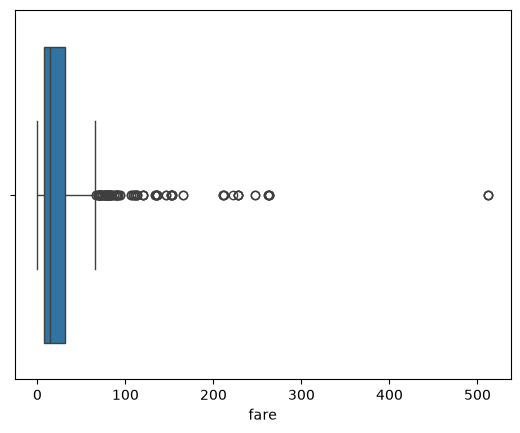

In [13]:
sns.boxplot(
    data=df,
    x='fare')
plt.show()

In [14]:
df['embark_town_dirty'] = df['embark_town_dirty'].replace('unknown', np.nan)


In [15]:
df['embark_town_dirty']=df['embark_town_dirty'].str.lower()

In [16]:
df['embark_town_dirty'].head(10)

0    southampton
1      cherbourg
2    southampton
3    southampton
4    southampton
5     queenstown
6    southampton
7    southampton
8    southampton
9      cherbourg
Name: embark_town_dirty, dtype: str

In [17]:
df2=pd.read_csv('titanic_dataset.csv')

In [18]:
df2.head(10)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


In [19]:
num= ['age', 'fare', 'parch', 'sibsp']
cat= ['survived','pclass', 'sex', 'embarked', 'class', 'who','adult_male', 'deck', 'embark_town_dirty', 'alive', 'alone']

In [20]:
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    str    
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    str    
 8   class        891 non-null    str    
 9   who          891 non-null    str    
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    str    
 12  embark_town  889 non-null    str    
 13  alive        891 non-null    str    
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), str(7)
memory usage: 92.4 KB


In [21]:
df2.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# Univariate/Numerical Column Analysis

In [22]:
print(f'Number of numerical columns = {len(num)}')
print(f'Number of categorical columns = {len(cat)}')

print('\n')

print(f'Mean of ALL numerical columns:')
for i in num:
    print(f'{i}')
    mean = df2[i].mean()
    skweness = df2[i].skew()
    kurtosis = df2[i].kurtosis()
    print(f'Mean of {i} = {mean}')
    print(f'Skewness of {i} = {skweness}')
    print(f'Kurtosis of {i} = {kurtosis} \n')


Number of numerical columns = 4
Number of categorical columns = 11


Mean of ALL numerical columns:
age
Mean of age = 29.69911764705882
Skewness of age = 0.38910778230082704
Kurtosis of age = 0.17827415364210353 

fare
Mean of fare = 32.204207968574636
Skewness of fare = 4.787316519674893
Kurtosis of fare = 33.39814088089868 

parch
Mean of parch = 0.38159371492704824
Skewness of parch = 2.7491170471010933
Kurtosis of parch = 9.778125179021648 

sibsp
Mean of sibsp = 0.5230078563411896
Skewness of sibsp = 3.6953517271630565
Kurtosis of sibsp = 17.880419726645968 



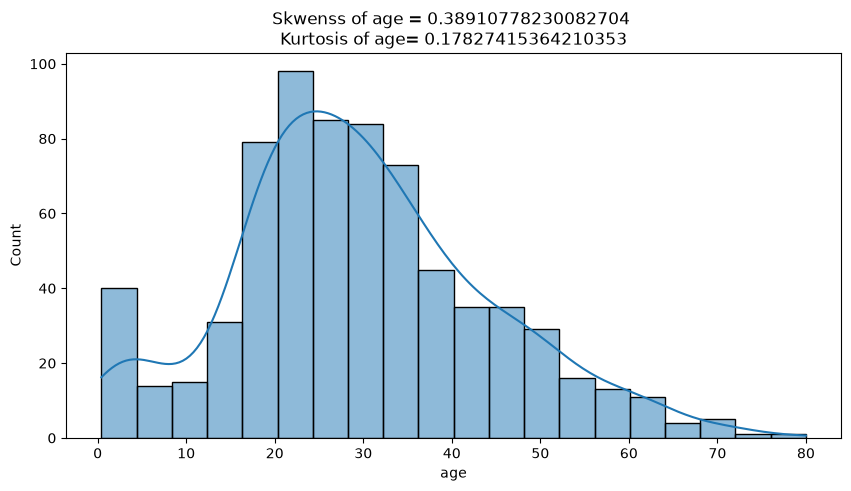

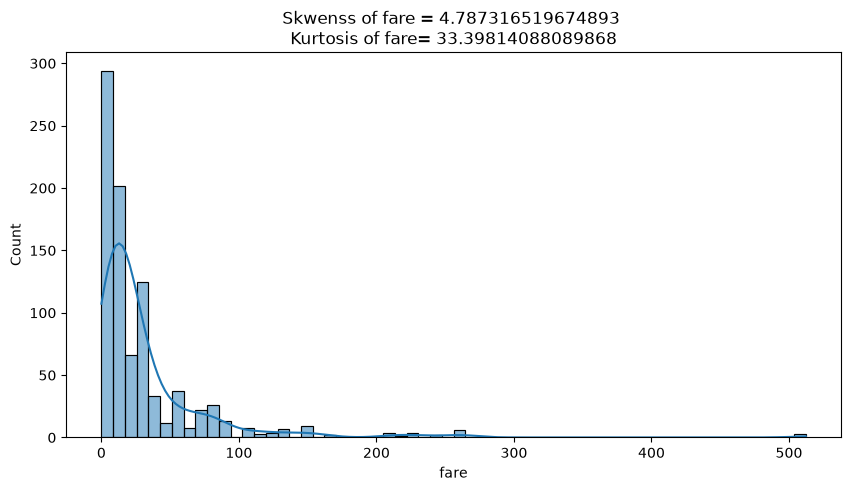

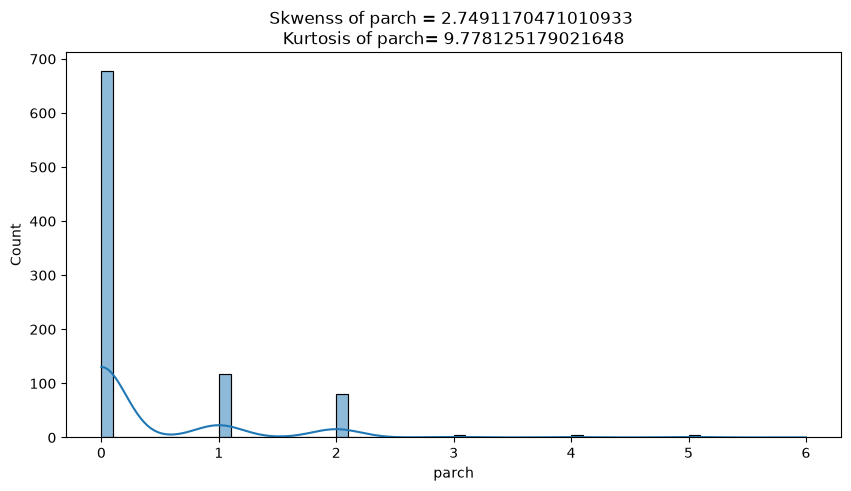

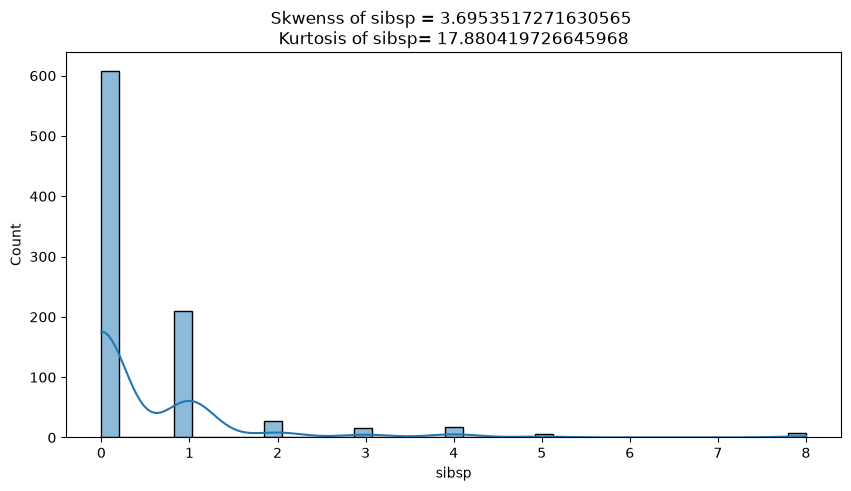

In [23]:
for i in num:
    plt.figure(figsize=(10, 5))
    sns.histplot(
          data=df2[i],
          kde=True)
    plt.title(f'Skwenss of {i} = {df2[i].skew()} \n Kurtosis of {i}= {df2[i].kurtosis()} ')
    plt.show()
    

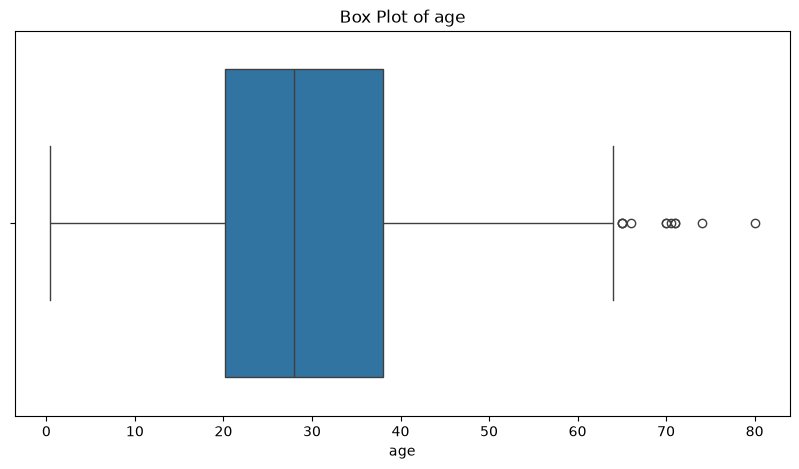

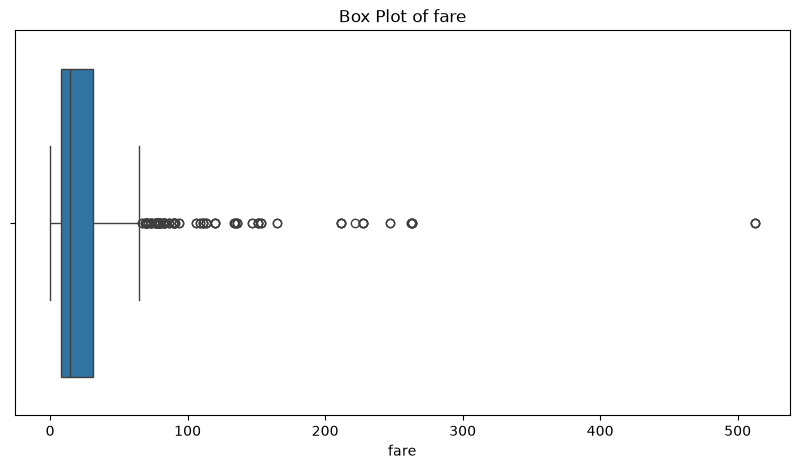

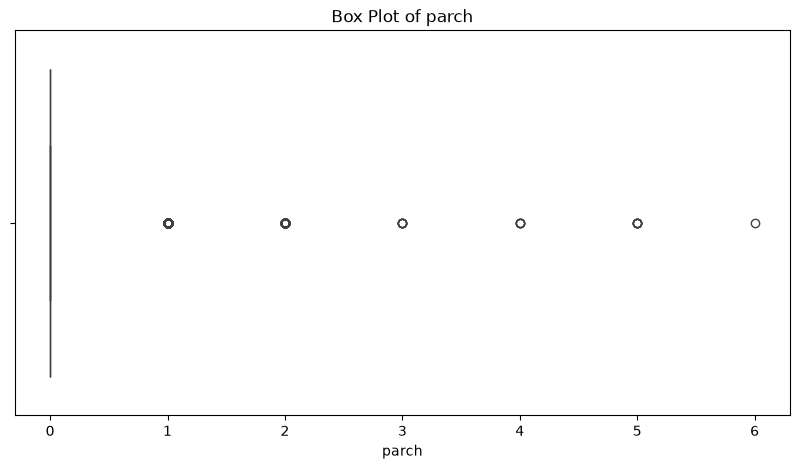

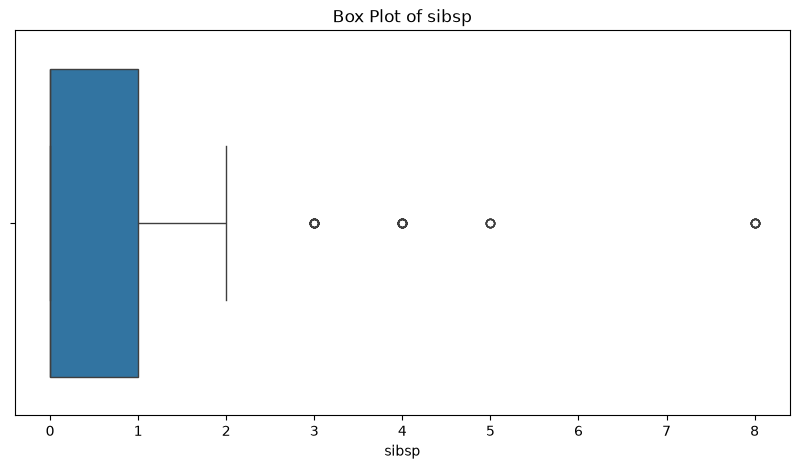

In [24]:
for i in num:
    plt.figure(figsize=(10,5))
    sns.boxplot(
        data=df2[i],
        orient='h')
    plt.title(f'Box Plot of {i}')
    plt.show()

# Bivariate Analysis

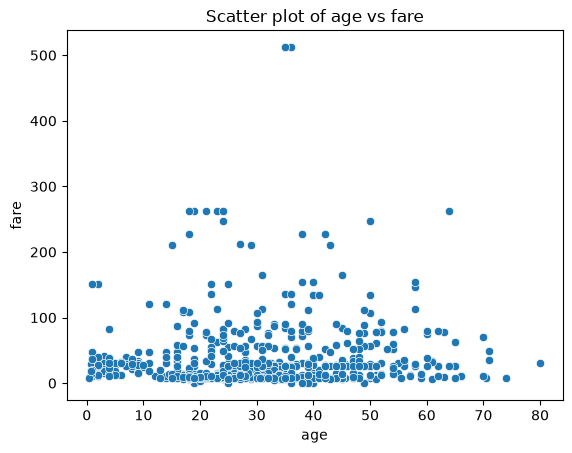

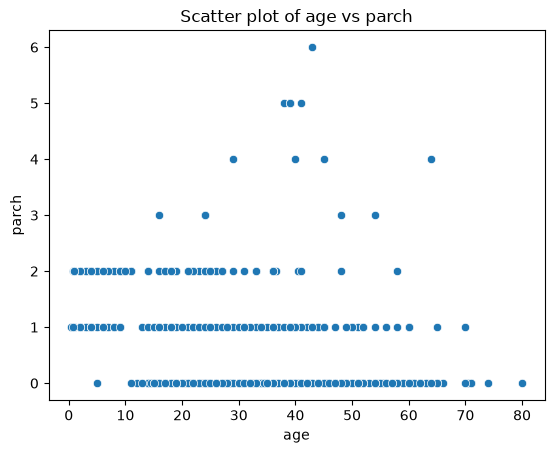

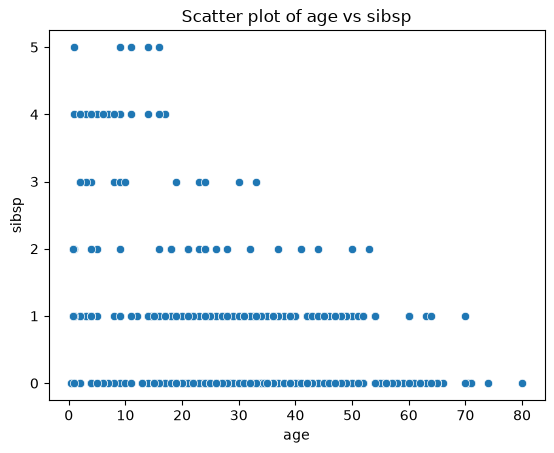

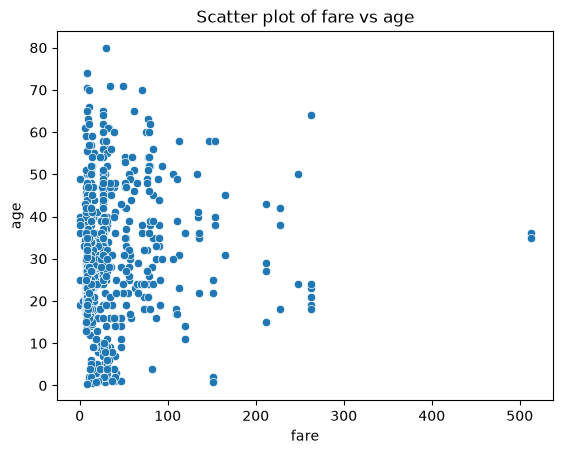

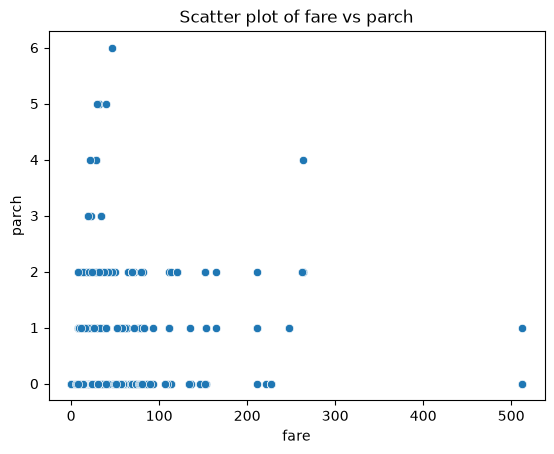

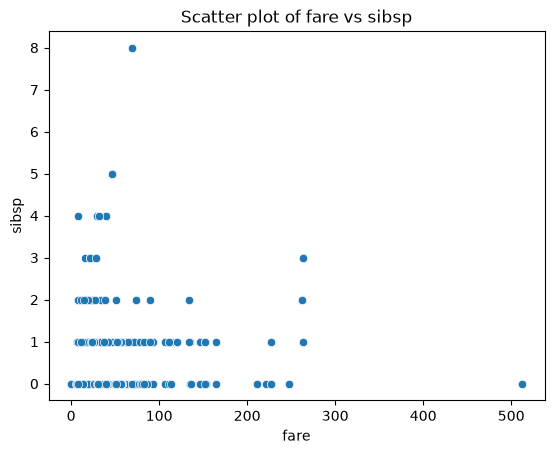

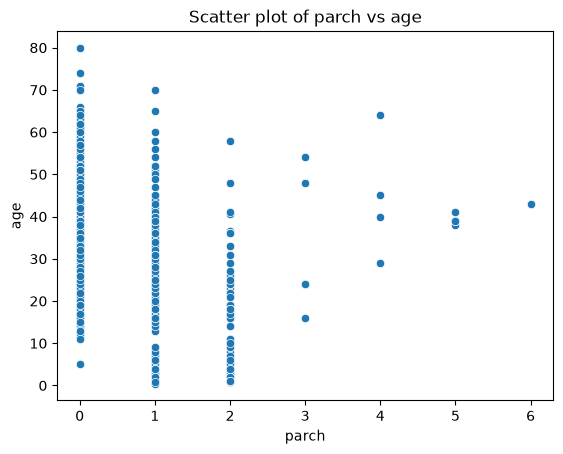

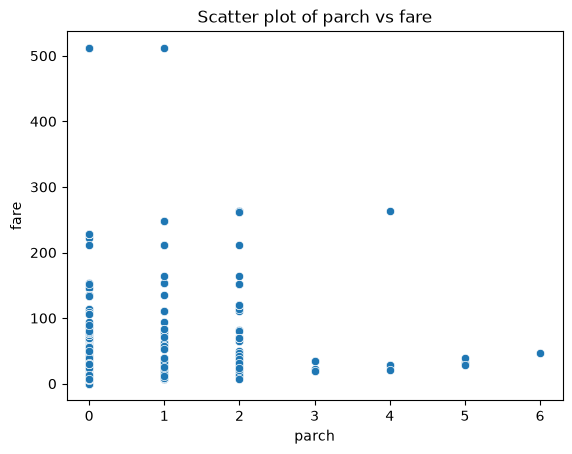

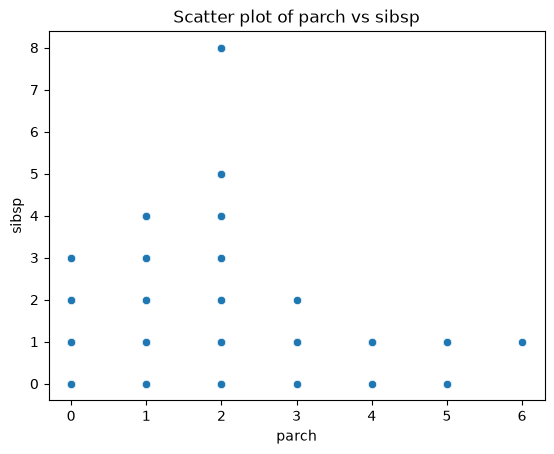

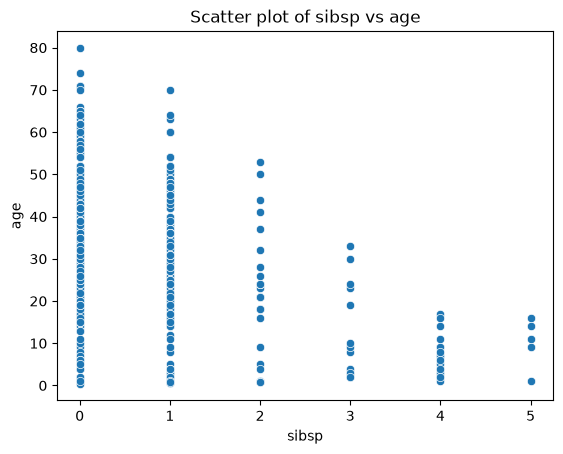

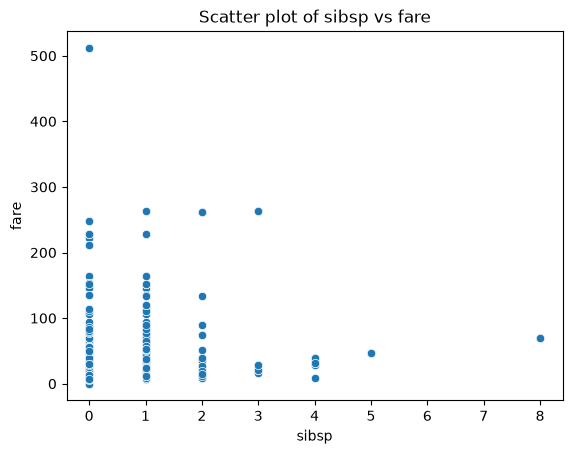

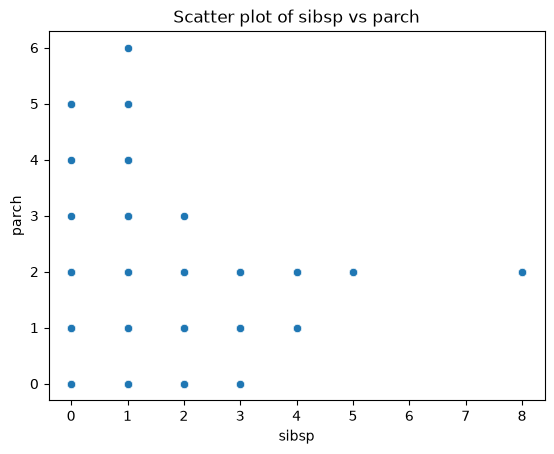

In [25]:
for i in num:
    for j in num:
        if( i != j ):
            sns.scatterplot(x=df2[i],
                             y=df2[j])
            plt.title(f'Scatter plot of {i} vs {j}')
            plt.show()

# Multivariate Analysis
  
  ## Pairplot

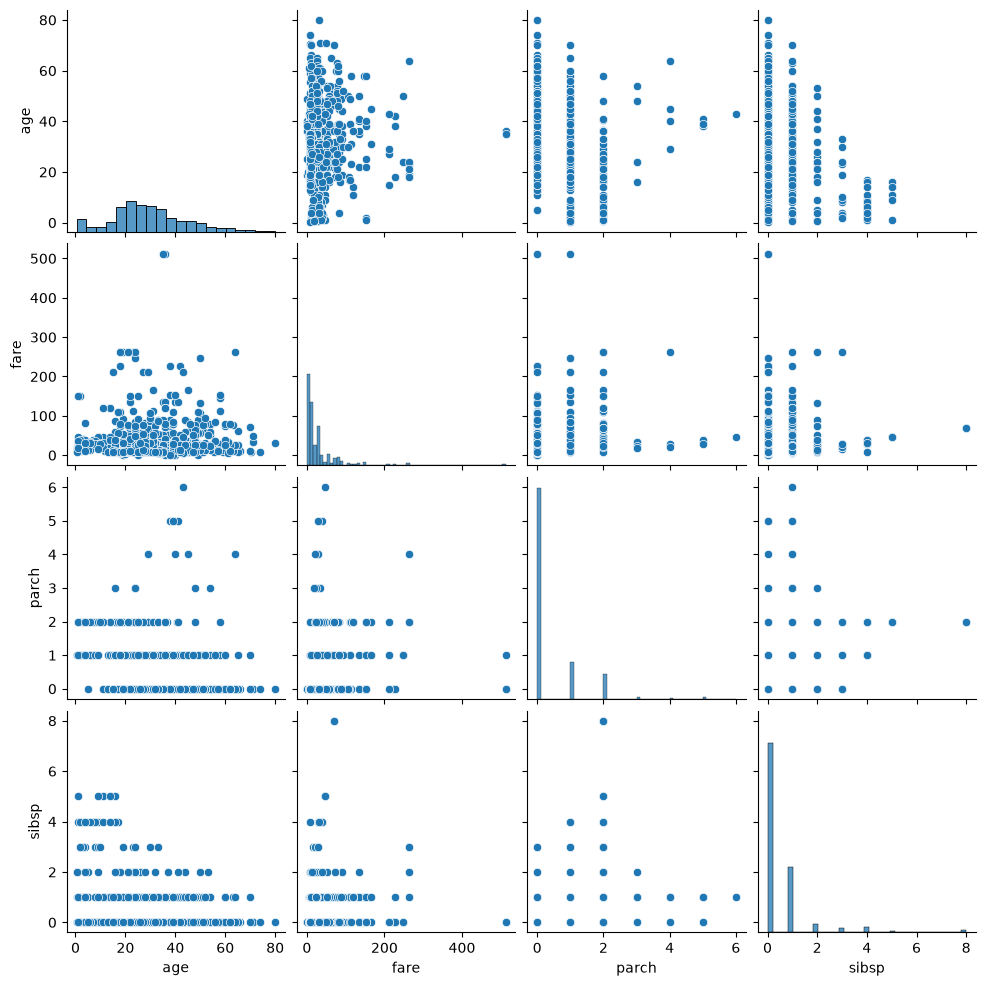

In [27]:
sns.pairplot(
    df2[num]
)
plt.show()

## HeatMap

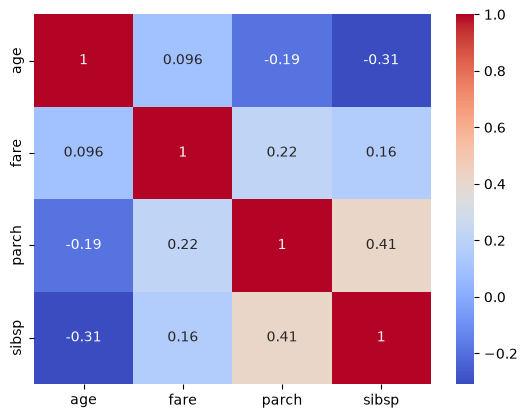

In [30]:
corr = df2[num].corr()
plt.Figure(figsize=[10,5])
sns.heatmap(
    data= corr,
    annot=True,
    cmap='coolwarm'
)
plt.show()